# **Predict Future Stock Prices (Short-Term)**

### **Install & Import Libraries**

In [ ]:
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

### **Fetch Stock Data**

In [ ]:
stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
stock.head()

/tmp/ipython-input-997466175.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400536,72.460799,71.156697,71.409800,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


### **Prepare Target Variable**

In [ ]:
stock["Next_Close"] = stock["Close"].shift(-1)
stock = stock.dropna()

### **Train-Test Split**

In [ ]:
X = stock[["Open", "High", "Low", "Volume"]]
y = stock["Next_Close"]

### **Train Model**

In [ ]:
train_size = int(len(stock) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

### **Random Forest**

In [ ]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

### **Evaluate Model**

In [ ]:
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)

Mean Squared Error: 101.24182087782741


### **Plot Actual vs Predicted**

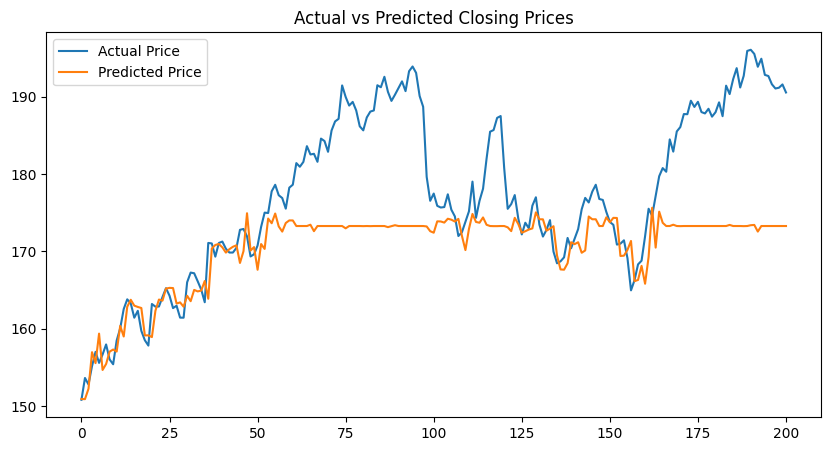

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Closing Prices")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 101.24182087782741
Root Mean Squared Error: 10.061899466692529


## Conclusion

In this project, historical stock data was used to predict
the next day's closing price using a Random Forest regression model.

The model successfully captured general price trends but
showed limitations in predicting short-term volatility.

This demonstrates the challenges of time series forecasting
in financial markets.

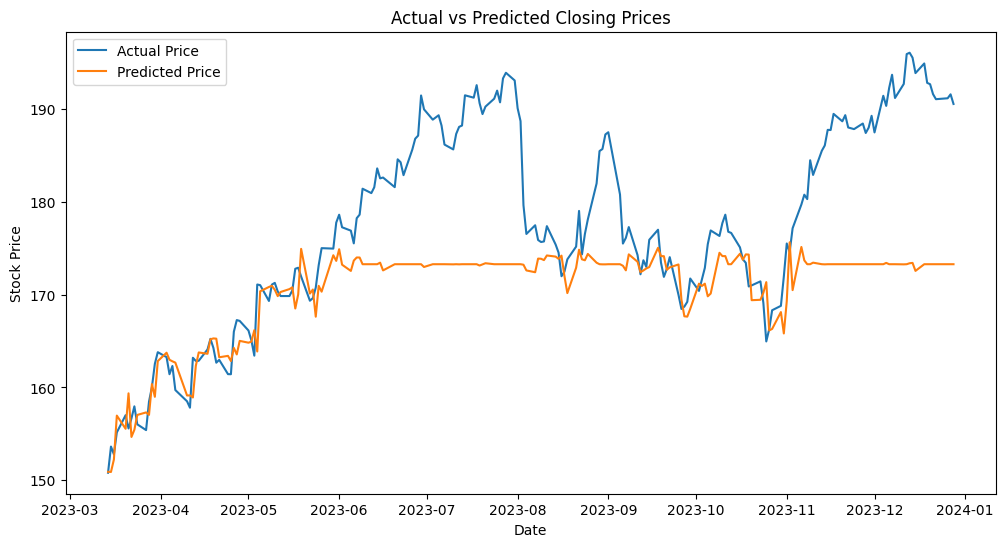

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(stock.index[train_size:], y_test, label="Actual Price")
plt.plot(stock.index[train_size:], predictions, label="Predicted Price")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.title("Actual vs Predicted Closing Prices")
plt.show()